# Módulo 33 - K-Means
## Segmentação de clientes

### Contexto
A segmentação de clientes é uma estratégia essencial para empresas que desejam compreender melhor o perfil e o comportamento de seus consumidores. Estudos em marketing e ciência de dados mostram que características como idade, renda anual, gênero e padrões de gastos variam significativamente entre grupos de clientes, refletindo necessidades e preferências distintas. A identificação desses grupos permite o desenvolvimento de ações mais direcionadas, como campanhas de marketing personalizadas e ofertas sob medida, aumentando a eficiência e o retorno das estratégias comerciais.

### Objetivo Geral
Aplicar a técnica de clusterização K-means para segmentar clientes com base em suas características demográficas e comportamentais, utilizando dados coletados de um conjunto de 200 clientes.

### Objetivos Complementares
* **Pré-processamento pt-1:** Verificar os tipos de variáveis disponíveis no dataset e
limpeza dos dados e exclusão de registros com informações faltantes.
* **Análise exploratória & descritiva:** Identificar possíveis agrupamentos de clientes por meio de suas características demográficas e de consumo.
* **Pré-processamento pt-2:** Padronizar os dados para garantir comparabilidade entre as variáveis;Realizar visualizações para melhor compreensão dos padrões e distribuição dos clientes.
* **Modelagem:** Aplicar o algoritmo K-means, definindo o número de clusters de acordo com a análise exploratória e os objetivos do negócio.
* **Avaliação:** Analisar os centroides dos clusters, dispersão dos grupos.

### Base de Dados
A base de dados contém 200 registros com  as seguintes features de acordo com a **Tabela 1**.
|             Features           | Tipo   |   Nulos | Mínimo   | Máximo   |
|:-----------------------|:-------|--------:|:---------|:---------|
| CustomerID             | int64  |       0 | 1        | 200      |
| Gender                 | object |       0 | Female   | Male     |
| Age                    | int64  |       0 | 18       | 70       |
| Annual Income (k$)     | int64  |       0 | 15       | 137      |
| Spending Score (1-100) | int64  |       0 | 1        | 99       |
**Tabela 1**




### 📂 1. Importação de Bibliotecas & dataload

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

cores=['dodgerblue','tomato','blueviolet','darkorange','forestgreen','crimson']
sns.set_palette(cores)

# Leitura dos dados
df = pd.read_csv('/home/akel/PycharmProjects/EBAC/dados/Mall_Customers.csv')
display(df.head())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 🧹 2. Pré-processamento: Tipos e limpeza de dados

In [154]:
# remover coluna CustomerID: Não carrega significado sobre o comportamento ou perfil do cliente.( não é previsível)
df.drop('CustomerID',axis=1,inplace=True)

#renomear colunas para melhor manipulação:
df.rename(columns={'Annual Income (k$)': 'annual_income'}, inplace=True)
df.rename(columns={'Spending Score (1-100)': 'score'}, inplace=True)

#renomear variavael categorica
#df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})

resume=pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    'Mínimo': df.min(),
    'Máximo': df.max()      
})
print(resume.to_markdown())

|               | Tipo   |   Nulos | Mínimo   | Máximo   |
|:--------------|:-------|--------:|:---------|:---------|
| Gender        | object |       0 | Female   | Male     |
| Age           | int64  |       0 | 18       | 70       |
| annual_income | int64  |       0 | 15       | 137      |
| score         | int64  |       0 | 1        | 99       |


>📌 Não há valores nulos nos dados. 



### 📊 3. Análise exploratória e descritiva


 Estatísticas descritivas:


,Age,annual_income,score
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


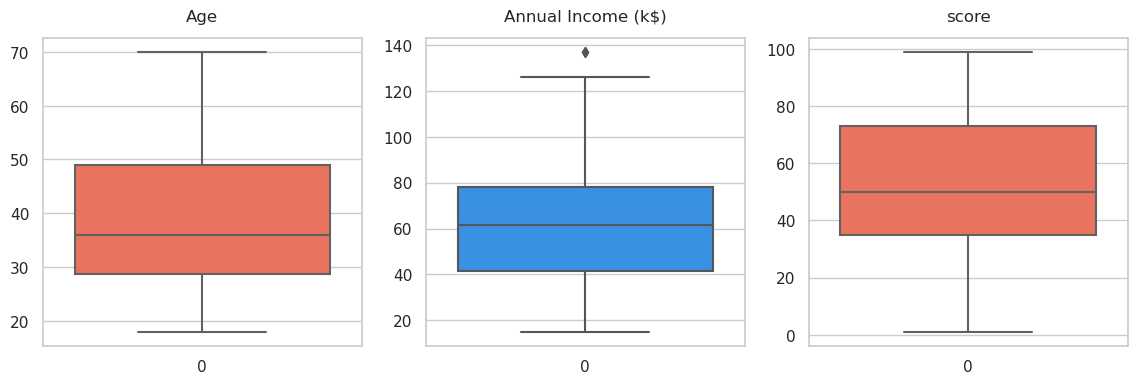

In [155]:
# Estatísticas descritivas
print("\n Estatísticas descritivas:")
display(df.describe())

fig, axs = plt.subplots(1,3, figsize=(14, 4))

sns.boxplot(data=df['Age'],color='tomato',ax=axs[ 0])
axs[0].set_title("Age", pad=12)

sns.boxplot(data=df['annual_income'],color='dodgerblue',ax=axs[ 1])
axs[ 1].set_title("Annual Income (k$)", pad=12)

sns.boxplot(data=df['score'], orient='v',color='tomato',ax=axs[ 2])
axs[ 2].set_title("score", pad=12)
plt.show()

>📌 **Considerações parciais**: Não foram observados outliers na features


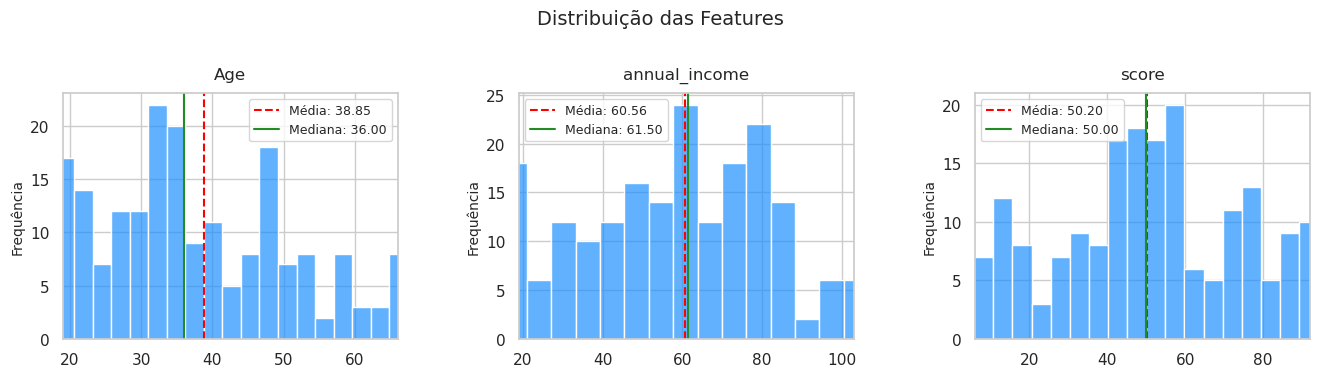

=======Teste Normalidade Shapiro-Wilk=====
Shapiro-Wilk (Age): p=0.000
Distribuição  NÃO é normal.
Shapiro-Wilk (annual_income): p=0.004
Distribuição  NÃO é normal.
Shapiro-Wilk (score): p=0.000
Distribuição  NÃO é normal.


In [156]:
# Configurar o estilo dos gráficos
sns.set(style="whitegrid")
# Lista das colunas e títulos
colunas = list(df.select_dtypes(include='number').columns)

# Defina o número de bins para cada variável
bins_var = [20,20,20]

# Histogramas (bins e counts) usando list comprehensions com bins variáveis
hist_bins_counts = [
    np.histogram(df[c].dropna(), bins=b) for c, b in zip(colunas, bins_var)
]

# DataFrame dos histogramas
histogram_df = pd.concat([
    pd.DataFrame({
        'bin_start': bins[:-1],
        'bin_end': bins[1:],
        'count': counts,
        'variable': var
    })
    for (counts, bins), var in zip(hist_bins_counts, colunas)
], ignore_index=True)

# Plot dos histogramas em subplots sem for e sem função customizada
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes = axes.flatten()

list(map(lambda i: [
    sns.histplot(df[colunas[i]], color='dodgerblue', bins=bins_var[i], alpha=0.7, ax=axes[i]),
    axes[i].axvline(df[colunas[i]].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Média: {df[colunas[i]].mean():.2f}'),
    axes[i].axvline(df[colunas[i]].median(), color='forestgreen', linestyle='-', linewidth=1.5, label=f'Mediana: {df[colunas[i]].median():.2f}'),
    axes[i].set_title(colunas[i], fontsize=12, pad=10),
    axes[i].set_xlabel(''),
    axes[i].set_ylabel('Frequência', fontsize=10),
    axes[i].legend(fontsize=9),
    axes[i].set_xlim(df[colunas[i]].quantile(0.05), df[colunas[i]].quantile(0.95))
], range(len(colunas))))

plt.tight_layout(pad=3.0)
plt.suptitle('Distribuição das Features', y=1.02, fontsize=14)
plt.show()


from scipy.stats import shapiro
print('=======Teste Normalidade Shapiro-Wilk=====')
for i in range(3):
    stat, p = shapiro(df[colunas[i]])
    print(f"Shapiro-Wilk ("+colunas[i] +f"): p={p:.3f}")
    if p < 0.05:
        print("Distribuição  NÃO é normal.")
    else:
        print("Distribuição PODE ser normal.")

>📌 **Considerações parciais:** Distribuição não é normal (Teste shapiro-wilk de normalidade(anexo). Assimetrias são observadas em todas as >distribuições, com algumas prevalências para jovens adultos  (30-36 anos), renda entre 45- 82k e score entre 45-60.


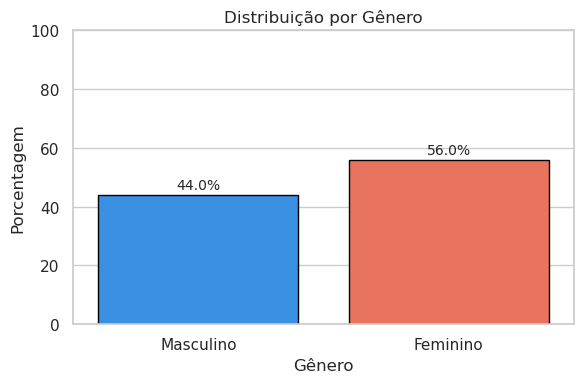

In [186]:

sns.set(palette=cores,style="whitegrid")

p1 = df['Gender'].value_counts(normalize=True) * 100

df_bar = pd.DataFrame({
    'Gênero': ['Masculino', 'Feminino'],
    'Porcentagem': [p1[1], p1[0]]})

# Plot com seaborn
plt.figure(figsize=(6, 4))
sns.barplot(data=df_bar, x='Gênero', y='Porcentagem', palette=cores, edgecolor='black')

# Título e anotações
plt.title('Distribuição por Gênero')
plt.ylim(0, 100)

# Adiciona os valores sobre as barras
for i, row in df_bar.iterrows():
    plt.text(i, row['Porcentagem'] + 1, f"{row['Porcentagem']:.1f}%", 
             ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

>📌 **Considerações parciais:** O gênero feminino é ligeiramente superior (56%) na base de dados de clientes.

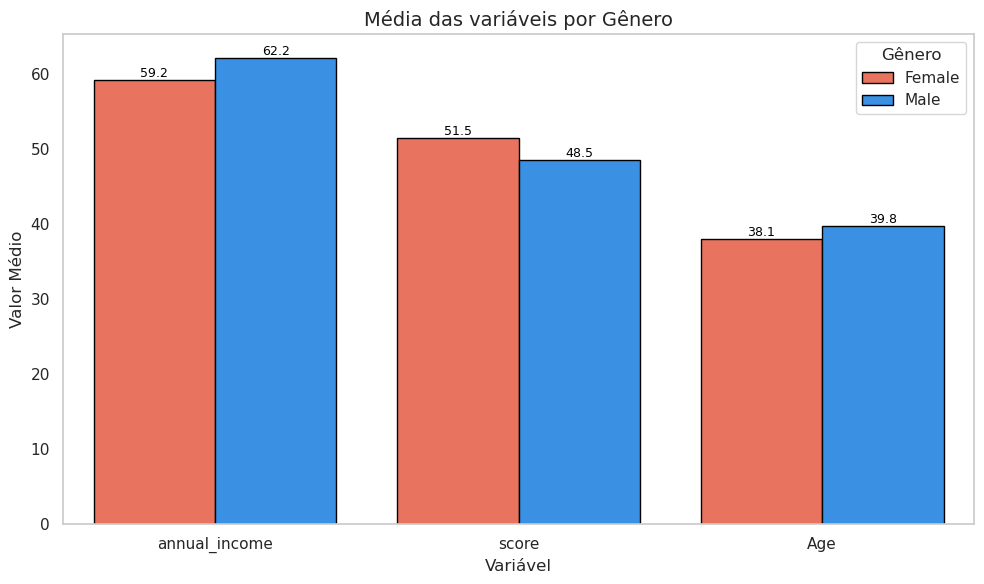

In [183]:
# agrupamento para comparar generos dfg -

dfg=df.copy() #dataframe com agrupamento
# Preparar DataFrame com médias agrupadas
means = dfg.groupby("Gender")[["annual_income", "score", "Age"]].mean().reset_index()

# organizando para colunas
means_melted = means.melt(id_vars="Gender", 
                          value_vars=["annual_income", "score", "Age"], 
                          var_name="Variável", 
                          value_name="Média")

# Gráfico de barras
plt.figure(figsize=(10, 6))
ax=sns.barplot(data=means_melted, x="Variável", y="Média", hue="Gender", palette=['tomato','dodgerblue' ], edgecolor='black')

plt.title("Média das variáveis por Gênero", fontsize=14)
plt.ylabel("Valor Médio")
plt.xlabel("Variável")
plt.legend(title="Gênero")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Adicionar os valores em cima das barras
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.1f}',  # texto com uma casa decimal
                (p.get_x() + p.get_width() / 2, height),  # posição (centro da barra, topo)
                ha='center', va='bottom', fontsize=9, color='black')

plt.tight_layout()
plt.show()


>📌 **Considerações parciais**: A distribuição da features baseada nos gênero, mostra que as diferenças são pequenas. Em média:
>* Homens têm renda ligeiramente maior(5%);
>* Mulheres tem um consumo ligeiramente maior(6%);
>* Homens são ligeiramente mais velhos(4%);

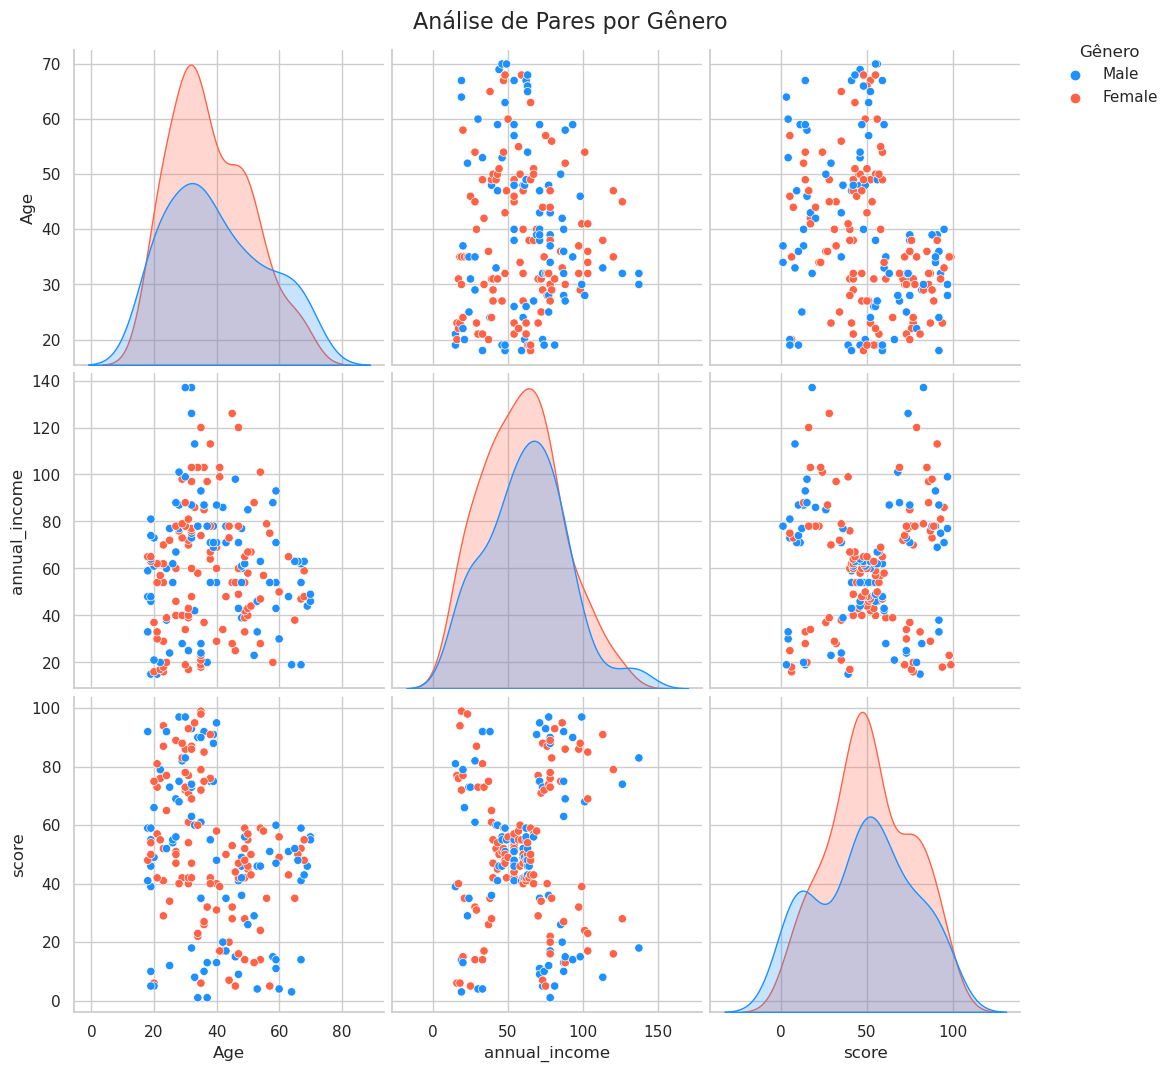

In [185]:
#Pairplot
p=sns.pairplot(df, hue="Gender",height=3.5, diag_kind="kde")
p.fig.suptitle("Análise de Pares por Gênero", fontsize=16, y=1.02)

p._legend.set_bbox_to_anchor((1.01, 0.95))
p._legend.set_title("Gênero")

plt.show();

>📌 **Considerações parciais:**
>
>* **Idade x renda :** Não há uma correlação clara,portanto jovens e idosas podem ter tanto rendas baixas quanto altas.
>* **Idade x Score :** sugerem diferentes padrões de consumo entre jovem e pessoas mais velhas. Não observamos score alto (>60) em pessoas acima de
>~40

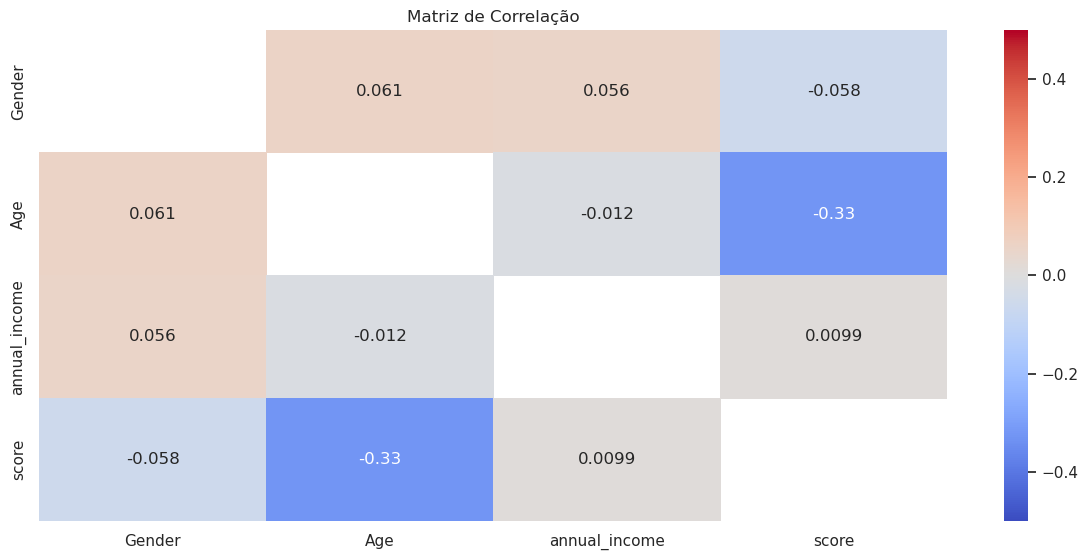

In [164]:
# Matriz de Correlação
dfn=df.copy() # dfn cópia de df atribuição binaria 0/1 para gênero 
dfn['Gender'] = dfn['Gender'].map({'Female': 0, 'Male': 1})
cm = dfn.corr()
cm[cm >=0.99] = pd.NA
#cm[(cm < 0.3)&(cm > -0.3)] = pd.NA
plt.figure(figsize=(12, 6))
sns.heatmap(cm,annot=True, cmap='coolwarm', vmin=-0.5, vmax=0.5)
plt.title('Matriz de Correlação')
plt.tight_layout(rect=[0.0, 0, 1, 0.96])

plt.show()

#colunas = list(df.select_dtypes(include='number').columns)

>📌 **Considerações parciais:**
>Apenas a correlação entre **Age** e **Score** mostram uma correlação negativa significativa(-0.33). Pessoas mais jovem tendem a ter um score maior.

### 🔧 4.Pré-Modelagem K-Means

In [168]:
# Pré-modelagem

# Inicializar o StandardScaler
scaler = StandardScaler()     # Inicializar o StandardScaler
# Seleção de colunas numéricas
X = dfn[colunas]               
# Ajustar e transformar os dados selecionados
X_scaled= scaler.fit_transform(X)

#### 4.1 Análise PCA

O PCA mostra se há padrões relevantes de separação entre gêneros usando apenas variáveis numéricas. Se não houver distinção clara entre os gêneros após o PCA, incluir "gender" no K-Means não é necessário. Assim, é possível justificar a exclusão de gênero do processo de clusterização.

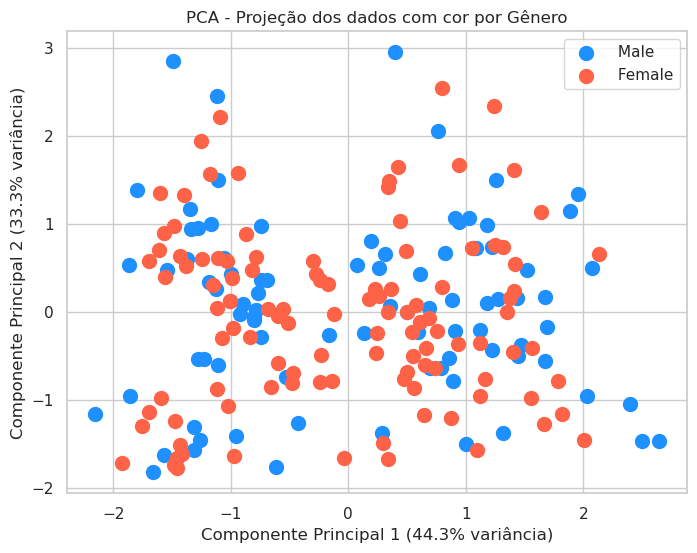

In [187]:
# Análise PCA
from sklearn.decomposition import PCA

# Aplicação do PCA para 2 componentes principais
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
explained_var = pca.explained_variance_ratio_

sns.set(palette=cores,style="whitegrid")
# Gráfico da projeção PCA colorido por gênero
plt.figure(figsize=(8, 6))
for gender in df['Gender'].unique():
    plt.scatter(X_pca[df['Gender'] == gender, 0],
                X_pca[df['Gender'] == gender, 1],
                label=f' {gender}', s=100)
plt.title('PCA - Projeção dos dados com cor por Gênero')
plt.xlabel(f'Componente Principal 1 ({explained_var[0]*100:.1f}% variância)')
plt.ylabel(f'Componente Principal 2 ({explained_var[1]*100:.1f}% variância)')
plt.legend()
plt.grid(True)
plt.show()

>📌 **Comentários:**\
>Ao analisar seu conjunto de dados — composto por idade, renda anual, score e gênero — foi aplicada uma Análise de Componentes Principais (PCA) apenas nas variáveis numéricas. O resultado mostrou que os dois primeiros componentes explicam juntos 77,63% da variância dos dados (sendo 44,3% pelo PC1 e 33,33% pelo PC2).Bom para visualização e compreensão dos padrões principais, 22,37% restante representa informações mais "sutis" ou ruído, que poderia ser relavante para tomadade de decisão mais crítériosa. Assim a maior parte das informações relevantes do dataset original pode ser representada em apenas duas dimensões, facilitando não só a visualização, mas também a segmentação eficiente dos perfis.
>A visualização dos pontos na projeção dos componentes principais, com gênero apenas como cor nos pontos do gráfico, mostrou que não há separação natural evidente entre M e F nesses eixos numéricos principais. Esses achados reforçam que a formação inicial dos clusters deve considerar somente as variáveis numéricas, deixando o gênero exclusivamente para análise posterior do perfil dos grupos.


#### 4.2 Definição do número de cluster
Aplicamos 4 diferentes métricas e técnicas para escolher o valor mais apropriado de K. Abaixo o critério para escolha de para cada técnica.
* **Inércia** : Mudança de comportamento da curva (redução da variância intra-cluster).
* **Índice de Silhueta**: Maior valor (separação dos clusters).
* **Calinski-Harabasz (CH)** : Maior valor (densidade dos grupos).
* **Davies-Bouldin (DB)** : Menor valor (similaridade entre os grupos).\
 
    **Objetivo**: Encontrar o valor de K que equilibre separação e compacidade dos clusters

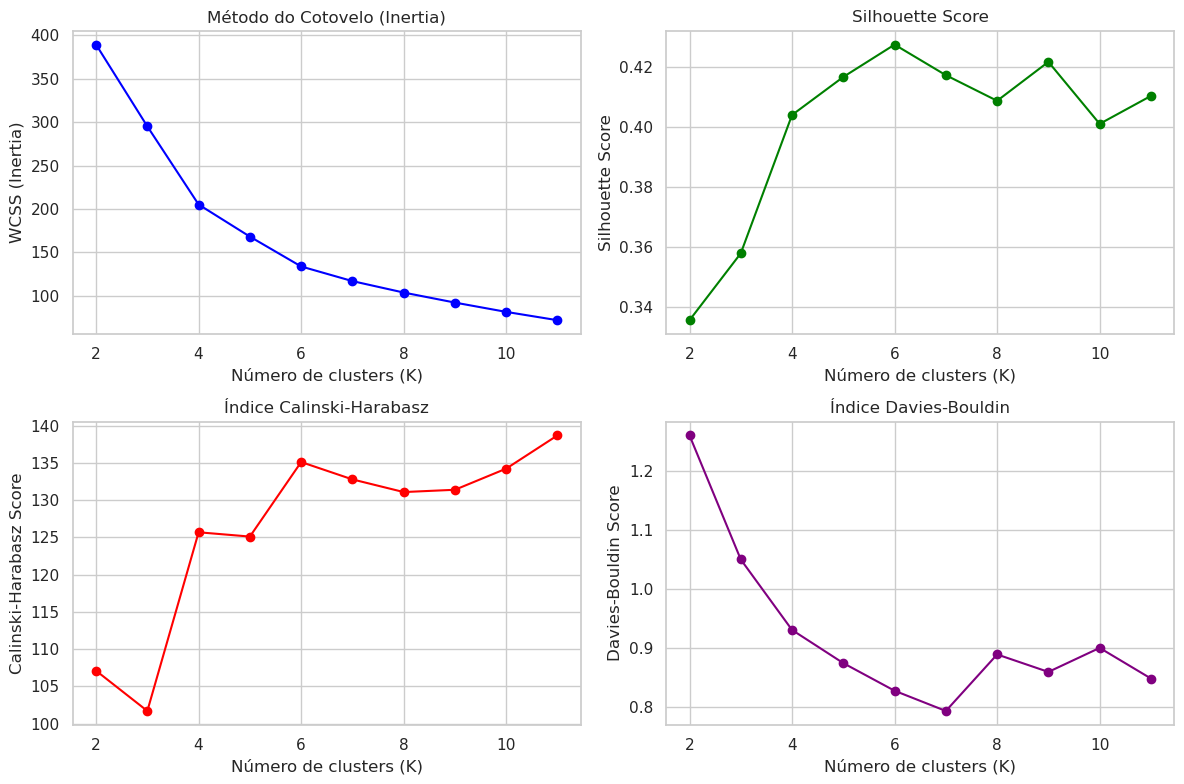

|       K |   Inertia |   Silhouette |   CH_Score |   DB_Score |
|--------:|----------:|-------------:|-----------:|-----------:|
|  2.0000 |  389.3862 |       0.3355 |   107.0956 |     1.2607 |
|  3.0000 |  295.2122 |       0.3578 |   101.6949 |     1.0503 |
|  4.0000 |  205.2251 |       0.4040 |   125.6764 |     0.9308 |
|  5.0000 |  168.2476 |       0.4166 |   125.1009 |     0.8746 |
|  6.0000 |  133.8683 |       0.4274 |   135.1022 |     0.8277 |
|  7.0000 |  117.0116 |       0.4172 |   132.7743 |     0.7935 |
|  8.0000 |  103.8286 |       0.4087 |   131.0744 |     0.8893 |
|  9.0000 |   92.2665 |       0.4217 |   131.3818 |     0.8596 |
| 10.0000 |   81.5458 |       0.4010 |   134.2209 |     0.9004 |
| 11.0000 |   71.9617 |       0.4103 |   138.6838 |     0.8485 |


In [35]:
# Número de cluster
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Intervalo de valores de K
K_range = range(2, 12)

# Listas para armazenar as métricas
inertia = []
silhouette_scores = []
ch_scores = []
db_scores = []

# Loop para cada valor de K
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=100)
    labels = kmeans.fit_predict(Xs)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(Xs, labels))
    ch_scores.append(calinski_harabasz_score(Xs, labels))
    db_scores.append(davies_bouldin_score(Xs, labels))

# Configuração do subplot 2x2
plt.figure(figsize=(12, 8))

# Subplot 1: Inertia (WCSS)
plt.subplot(2, 2, 1)
plt.plot(K_range, inertia, marker='o', color='blue')
plt.title('Método do Cotovelo (Inertia)')
plt.xlabel('Número de clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)

# Subplot 2: Silhouette Score
plt.subplot(2, 2, 2)
plt.plot(K_range, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Score')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)

# Subplot 3: Calinski-Harabasz Score
plt.subplot(2, 2, 3)
plt.plot(K_range, ch_scores, marker='o', color='red')
plt.title('Índice Calinski-Harabasz')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Calinski-Harabasz Score')
plt.grid(True)

# Subplot 4: Davies-Bouldin Score
plt.subplot(2, 2, 4)
plt.plot(K_range, db_scores, marker='o', color='purple')
plt.title('Índice Davies-Bouldin')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Davies-Bouldin Score')
plt.grid(True)

# Ajusta layout e mostra o gráfico
plt.tight_layout()
plt.show()
    

metrics_K = pd.DataFrame({
    'K': K_range,
    'Inertia': inertia,
    'Silhouette': silhouette_scores,
    'CH_Score': ch_scores,
    'DB_Score': db_scores
})

# Print as Markdown table
print(metrics_K.to_markdown(index=False, floatfmt=".4f"))

Tendências observadas:
* **Inércia:** cai rapidamente, mas a queda desacelera bastante após K=6 ou K=7 (ponto de "cotovelo").
* **Índice de Silhueta :** atinge o pico em K=6 (0,4274) e depois começa a diminuir.
* **Calinski-Harabasz** atinge o pico em K=6  (290) oscila os valores;
* **Davies-Bouldin** cai constantemente, atingindo o menor valor em K=7 mas a diferença em relação a K=6 já é bem pequena.

Desta forma **K=6** é o ponto de equilibrio entre todas as abordagens empregadas. Porém, a depender da representação visual dos grupos, é possivel aglutinar 1 ou mais grupos, de forma K ser menor que 6.


### 5.Modelagem K-means
O modelo K-means foi configurado com três parâmetros: 
* **n_clusters = 6** : Foi escolhido para refletir as três espécies de pinguins (Adélie, Gentoo e Chinstrap), garantindo que a estrutura natural dos dados fosse respeitada. 
* **n_init = 100**: assegura que o algoritmo execute múltiplas inicializações aleatórias dos centróides, selecionando a melhor solução em termos de minimização da variância intra-cluster, o que evita resultados subótimos devido a centróides mal posicionados na primeira tentativa. 
* **random_state = 42**:, é a semente pseudo-aleatória, para garantir a reprodutividade dos resultados. 

In [139]:
# modelagem K-means

# X_scaled é o dataset normalizado, sem variavel categórica, definido na pré-modelagem
K = 6
kmeans_clients = KMeans(n_clusters=K,n_init=100,random_state=42 )
kmeans_clients.fit(X_scaled)

# Centroides
centroides = kmeans_clients.cluster_centers_

# Centroides padronizados retornados pelo k-means
centroides_padronizados = kmeans_clients.cluster_centers_  
labels = kmeans_clients.labels_

# Inverter a padronização para obter os centroides originais
centroides_originais = scaler.inverse_transform(centroides_padronizados)

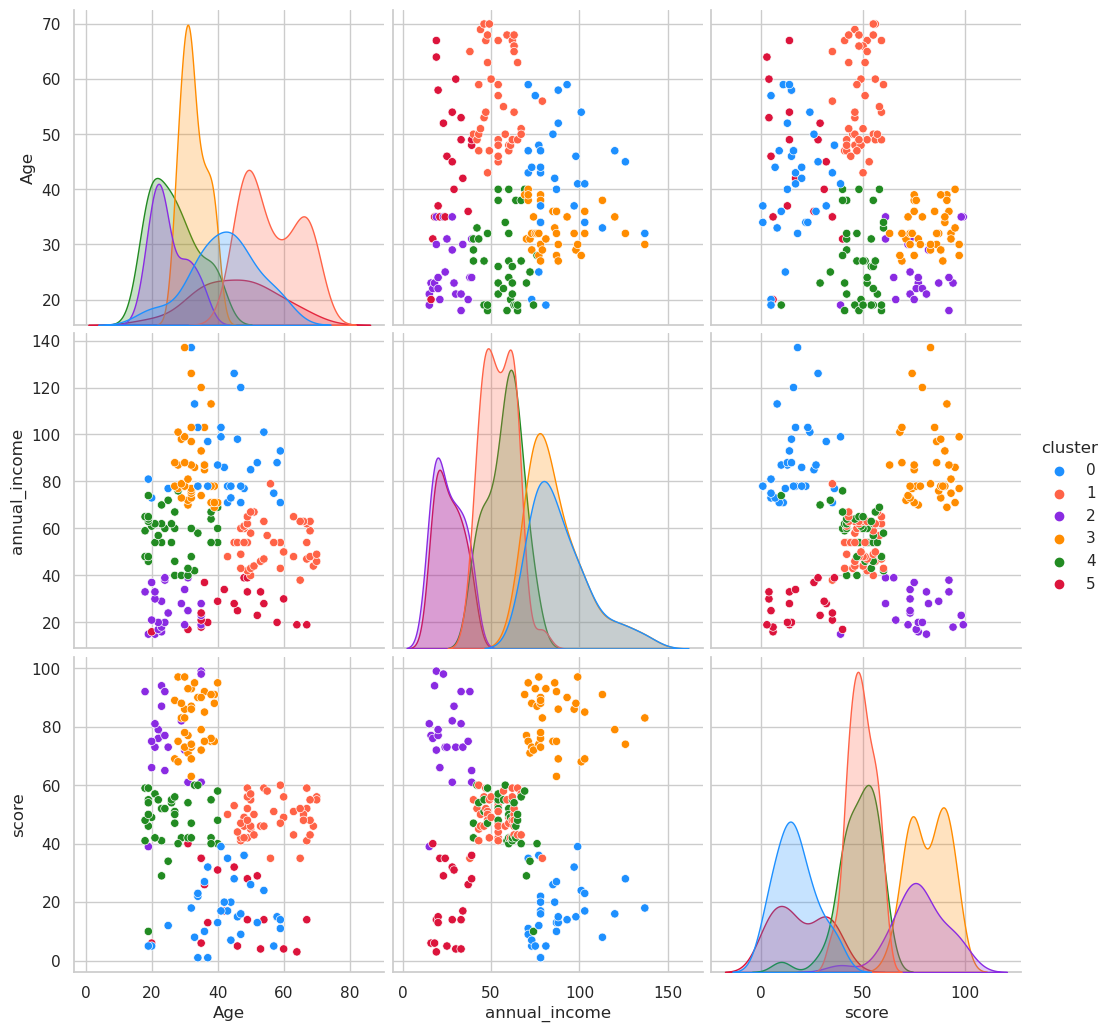

In [188]:
# Criação do dataframe com clusters
df_clusters = pd.DataFrame({
    'Age': dfn['Age'],
    'annual_income': dfn['annual_income'],
    'score': dfn['score'],
    'Gender': dfn['Gender'],
    'cluster': labels.astype(str)  # Convertendo clusters para string (para cores categóricas)
})

# Garantir ordenamento dos cluster
cluster_order = sorted(df_clusters['cluster'].unique())

sns.pairplot(df_clusters.drop(columns=["Gender"]),height=3.5,hue='cluster',hue_order=cluster_order)
p.fig.suptitle("Agrupamentos K=6", fontsize=16, y=1.02)

p._legend.set_bbox_to_anchor((1.01, 0.95))
p._legend.set_title("Clusters")

plt.show();

In [198]:
df_clusters_0=df_clusters[df_clusters['Gender']==0]
df_clusters_1=df_clusters[df_clusters['Gender']==1]
x=df_clusters.columns.get_loc('Age')
y=df_clusters.columns.get_loc('annual_income')
print(centroides_originais[:, x])
print(centroides_originais[:, y])

[41.93939394 56.33333333 25.25       32.69230769 26.68421053 45.52380952]
[88.93939394 54.26666667 25.83333333 86.53846154 57.57894737 26.28571429]


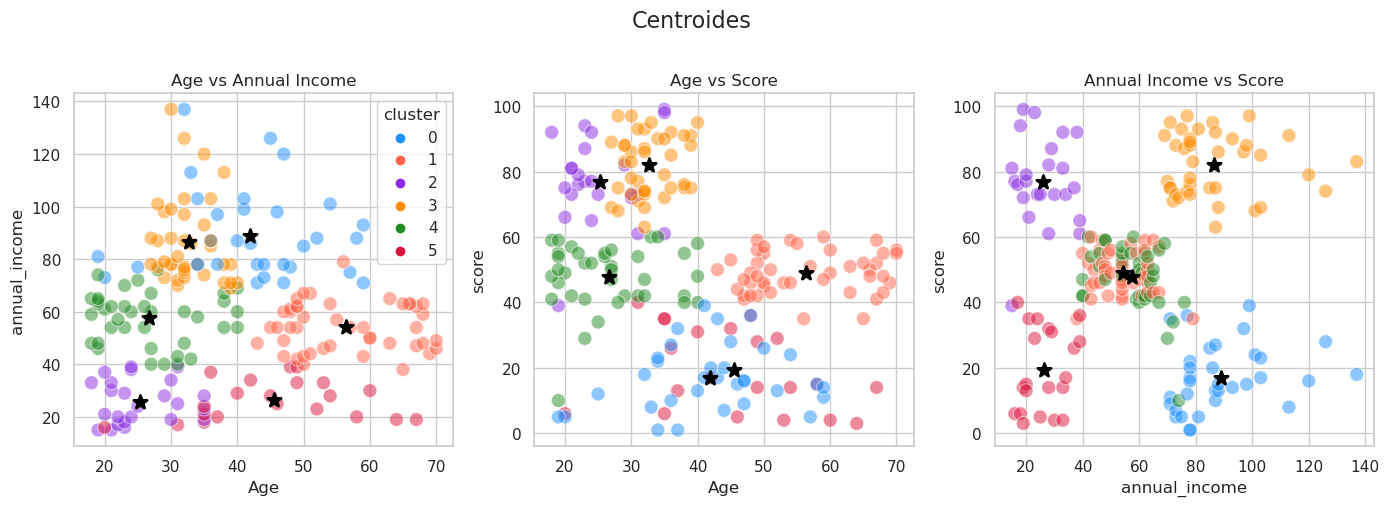

In [210]:
# Tamanho da figura
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Centroides", fontsize=16, y=1.01)

# Scatterplots 
sns.scatterplot(data=df_clusters, x='Age', y='annual_income',
                hue='cluster',hue_order=cluster_order,alpha=0.5,s=100,
                ax=axes[0])
axes[0].set_title('Age vs Annual Income')
x=df_clusters.columns.get_loc('Age')
y=df_clusters.columns.get_loc('annual_income')
axes[0].scatter(centroides_originais[:, x], centroides_originais[:, y], 
                 marker='*', color='black', s=100, linewidths=2,
                 label='Centroides')


sns.scatterplot(data=df_clusters, x='Age', y='score',
                hue='cluster', hue_order=cluster_order, legend=False,alpha=0.5,s=100,
                ax=axes[1])
axes[ 1].set_title('Age vs Score')
x=df_clusters.columns.get_loc('Age')
y=df_clusters.columns.get_loc('score')
axes[1].scatter(centroides_originais[:, x], centroides_originais[:, y], 
                 marker='*', color='black', s=100, linewidths=2,
                 label='Centroides')

sns.scatterplot(data=df_clusters, x='annual_income', y='score',
                 hue='cluster', hue_order=cluster_order, legend=False,alpha=0.5,s=100,
                ax=axes[ 2])
axes[2].set_title('Annual Income vs Score')
x=df_clusters.columns.get_loc('annual_income')
y=df_clusters.columns.get_loc('score')
axes[2].scatter(centroides_originais[:, x], centroides_originais[:, y], 
                 marker='*', color='black', s=100, linewidths=2,
                 label='Centroides')


# Ajustar layout
plt.tight_layout()
plt.show()


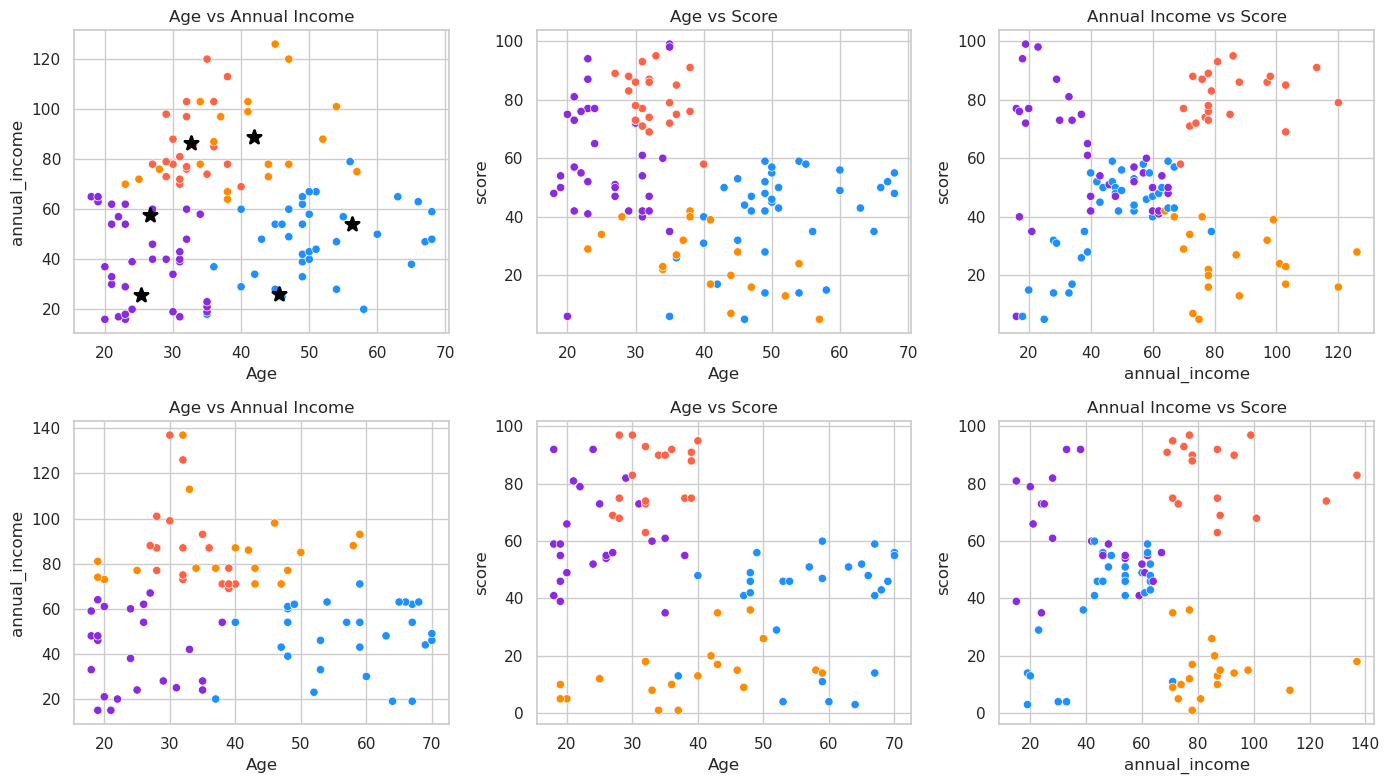

1

In [189]:
# # Tamanho da figura
# fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# # Scatterplots 
# sns.scatterplot(data=df_clusters_0, x='Age', y='annual_income',
#                 hue='cluster',hue_order=cluster_order,legend=False,
#                 ax=axes[0, 0])
# axes[0, 0].set_title('Age vs Annual Income')

# x=df_clusters.columns.get_loc('Age')
# y=df_clusters.columns.get_loc('annual_income')
# axes[0,0].scatter(centroides_originais[:, x], centroides_originais[:, y], 
#                  marker='*', color='black', s=100, linewidths=2,
#                  label='Centroides')


# sns.scatterplot(data=df_clusters_0, x='Age', y='score',
#                 hue='cluster', hue_order=cluster_order, legend=False,
#                 ax=axes[0, 1])
# axes[0, 1].set_title('Age vs Score')

# sns.scatterplot(data=df_clusters_0, x='annual_income', y='score',
#                  hue='cluster', hue_order=cluster_order, legend=False,
#                 ax=axes[0, 2])
# axes[0, 2].set_title('Annual Income vs Score')



# # Scatterplots manuais
# sns.scatterplot(data=df_clusters_1, x='Age', y='annual_income',
#                 hue='cluster',hue_order=cluster_order,legend=False,
#                 ax=axes[1, 0])
# axes[1, 0].set_title('Age vs Annual Income')

# sns.scatterplot(data=df_clusters_1, x='Age', y='score',
#                 hue='cluster', hue_order=cluster_order, legend=False,
#                 ax=axes[1, 1])
# axes[1, 1].set_title('Age vs Score')

# sns.scatterplot(data=df_clusters_1, x='annual_income', y='score',
#                  hue='cluster', hue_order=cluster_order, legend=False,
#                 ax=axes[1, 2])
# axes[1, 2].set_title('Annual Income vs Score')

# # Remove o subplot vazio (2x2 = 4 plots, mas temos só 3)

# # Ajustar layout
# plt.tight_layout()
# plt.show()
# y

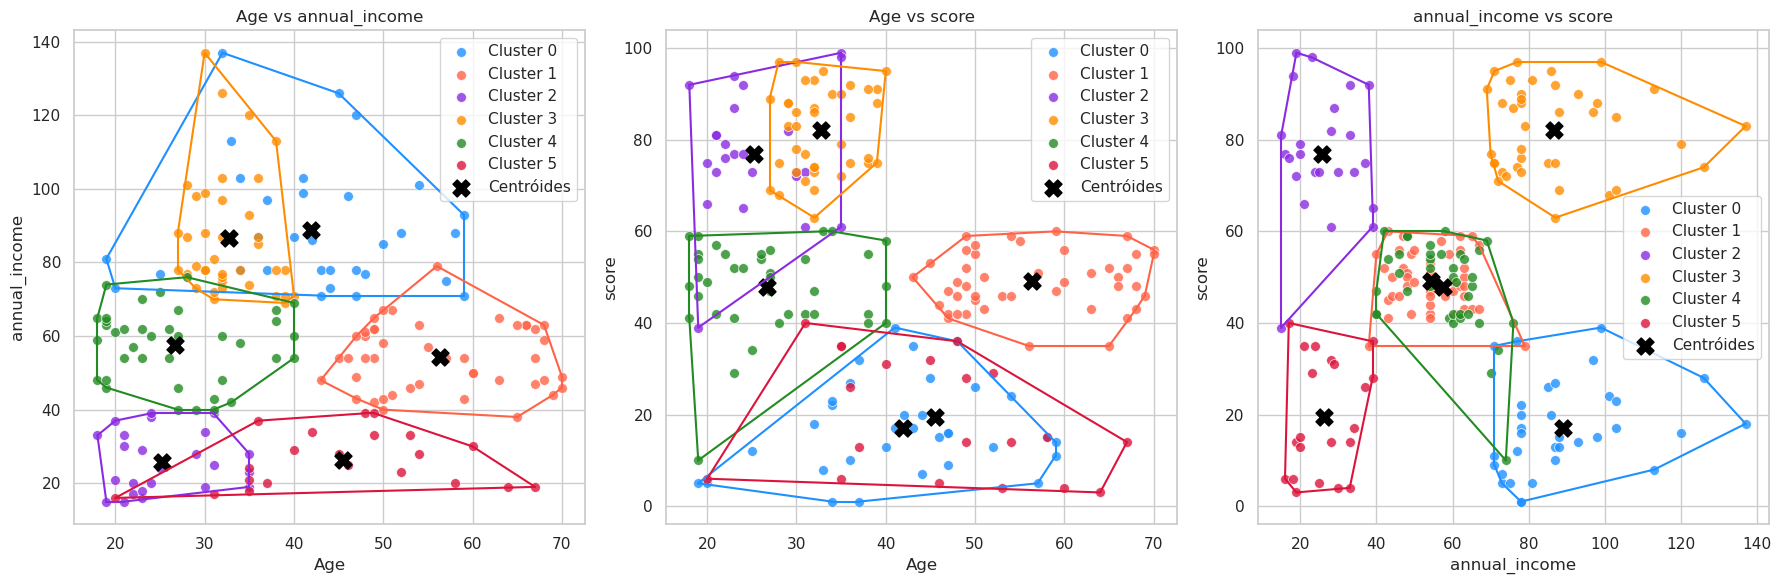

'crimson'

In [196]:
from scipy.spatial import ConvexHull



# Garantir que 'cluster' seja tratado como string para categorização
df_clusters['cluster'] = df_clusters['cluster'].astype(str)

# Lista dos pares de variáveis a serem plotados
var_pairs = [
    ('Age', 'annual_income'),
    ('Age', 'score'),
    ('annual_income', 'score')
]

# Cores fixas por cluster
unique_clusters = sorted(df_clusters['cluster'].unique())
#palette = sns.color_palette("tab10", n_colors=len(unique_clusters))
cores=['dodgerblue','tomato','blueviolet','darkorange','forestgreen','crimson']
sns.set_palette(cores)
cluster_color_map = {cluster: cores[i] for i, cluster in enumerate(unique_clusters)}

# Criação da figura com subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False, sharey=False)

# Iterar sobre os pares de variáveis e eixos
for ax, (x_var, y_var) in zip(axes, var_pairs):
    for cluster_id in unique_clusters:
        cluster_data = df_clusters[df_clusters['cluster'] == cluster_id]
        cor = cluster_color_map[cluster_id]

        # Pontos dos dados
        sns.scatterplot(
            x=cluster_data[x_var],
            y=cluster_data[y_var],
            color=cor,
            label=f'Cluster {cluster_id}',
            ax=ax,
            s=50,
            alpha=0.8
        )

        # Convex Hull
        if len(cluster_data) >= 5:
            points = cluster_data[[x_var, y_var]].values
            hull = ConvexHull(points)
            for simplex in hull.simplices:
                ax.plot(points[simplex, 0], points[simplex, 1], color=cor, linewidth=1.5)

    # Centróides
    x_idx = df_clusters.columns.get_loc(x_var)
    y_idx = df_clusters.columns.get_loc(y_var)
    ax.scatter(
        centroides_originais[:, x_idx],
        centroides_originais[:, y_idx],
        marker='X',
        color='black',
        s=150,
        label='Centróides'
    )

    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_title(f'{x_var} vs {y_var}')
    ax.legend()

plt.tight_layout()
plt.show()


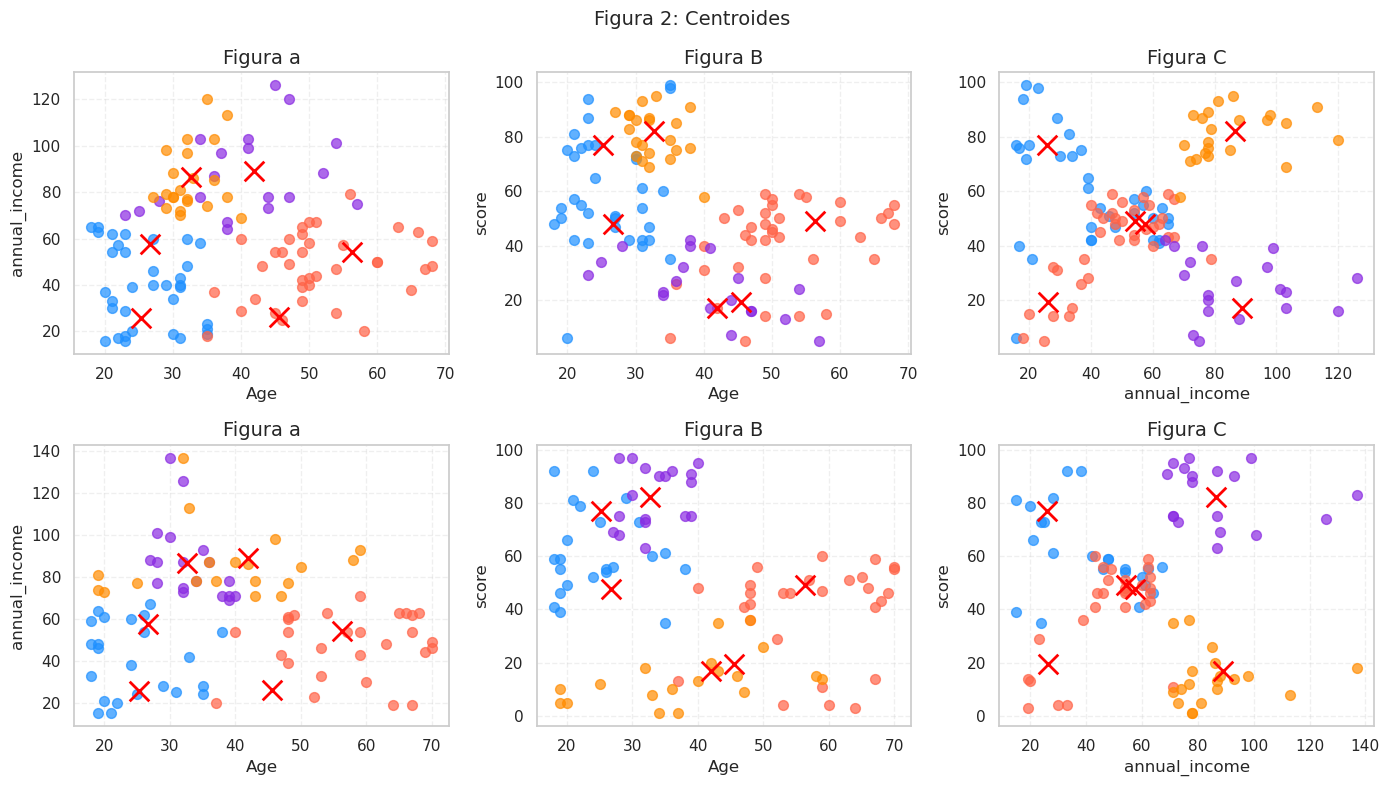

In [197]:
#plotar 2x3 - linha superior 0
#              linha inferior 1
#comparar os centroides

fig, ax = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Figura 2: Centroides', fontsize=14)

# EIXOS 
A = 'Age'
B = 'annual_income'
# Plotar pontos coloridos por cluster
for cluster in df_clusters_0['cluster'].unique():
    cluster_data = df_clusters_0[df_clusters_0['cluster'] == cluster]
    ax[0,0].scatter(cluster_data[A], cluster_data[B], label=f'Cluster {cluster}', alpha=0.7,s=50)

x=df_clusters_0.columns.get_loc(A)
y=df_clusters_0.columns.get_loc(B)
ax[0,0].scatter(centroides_originais[:, x], centroides_originais[:, y], marker='x', color='red', s=200, linewidths=2, label='Centroides')
ax[0,0].set_title('Figura a', fontsize=14)
ax[0,0].set_xlabel('Age', fontsize=12)
ax[0,0].set_ylabel('annual_income', fontsize=12)
ax[0,0].grid(True, linestyle='--', alpha=0.3)

A = 'Age'
B = 'score'
# Plotar pontos coloridos por cluster
for cluster in df_clusters_0['cluster'].unique():
    cluster_data = df_clusters_0[df_clusters_0['cluster'] == cluster]
    ax[0,1].scatter(cluster_data[A], cluster_data[B], label=f'Cluster {cluster}', alpha=0.7,s=50)

x=df_clusters_0.columns.get_loc(A)
y=df_clusters_0.columns.get_loc(B)
ax[0,1].scatter(centroides_originais[:, x], centroides_originais[:, y], marker='x', color='red', s=200, linewidths=2, label='Centroides')
ax[0,1].set_title('Figura B', fontsize=14)
ax[0,1].set_xlabel('Age', fontsize=12)
ax[0,1].set_ylabel('score', fontsize=12)
ax[0,1].grid(True, linestyle='--', alpha=0.3)

A = 'annual_income'
B = 'score'
# Plotar pontos coloridos por cluster
for cluster in df_clusters_0['cluster'].unique():
    cluster_data = df_clusters_0[df_clusters_0['cluster'] == cluster]
    ax[0,2].scatter(cluster_data[A], cluster_data[B], label=f'Cluster {cluster}', alpha=0.7,s=50)

x=df_clusters_0.columns.get_loc(A)
y=df_clusters_0.columns.get_loc(B)
ax[0,2].scatter(centroides_originais[:, x], centroides_originais[:, y], marker='x', color='red', s=200, linewidths=2, label='Centroides')
ax[0,2].set_title('Figura C', fontsize=14)
ax[0,2].set_xlabel('annual_income', fontsize=12)
ax[0,2].set_ylabel('score', fontsize=12)
ax[0,2].grid(True, linestyle='--', alpha=0.3)


# EIXOS 
A = 'Age'
B = 'annual_income'
# Plotar pontos coloridos por cluster
for cluster in df_clusters_1['cluster'].unique():
    cluster_data = df_clusters_1[df_clusters_1['cluster'] == cluster]
    ax[1,0].scatter(cluster_data[A], cluster_data[B], label=f'Cluster {cluster}', alpha=0.7,s=50)

x=df_clusters_1.columns.get_loc(A)
y=df_clusters_1.columns.get_loc(B)
ax[1,0].scatter(centroides_originais[:, x], centroides_originais[:, y], marker='x', color='red', s=200, linewidths=2, label='Centroides')
ax[1,0].set_title('Figura a', fontsize=14)
ax[1,0].set_xlabel('Age', fontsize=12)
ax[1,0].set_ylabel('annual_income', fontsize=12)
ax[1,0].grid(True, linestyle='--', alpha=0.3)

A = 'Age'
B = 'score'
# Plotar pontos coloridos por cluster
for cluster in df_clusters_1['cluster'].unique():
    cluster_data = df_clusters_1[df_clusters_1['cluster'] == cluster]
    ax[1,1].scatter(cluster_data[A], cluster_data[B], label=f'Cluster {cluster}', alpha=0.7,s=50)

x=df_clusters_1.columns.get_loc(A)
y=df_clusters_1.columns.get_loc(B)
ax[1,1].scatter(centroides_originais[:, x], centroides_originais[:, y], marker='x', color='red', s=200, linewidths=2, label='Centroides')
ax[1,1].set_title('Figura B', fontsize=14)
ax[1,1].set_xlabel('Age', fontsize=12)
ax[1,1].set_ylabel('score', fontsize=12)
ax[1,1].grid(True, linestyle='--', alpha=0.3)

A = 'annual_income'
B = 'score'
# Plotar pontos coloridos por cluster
for cluster in df_clusters_1['cluster'].unique():
    cluster_data = df_clusters_1[df_clusters_1['cluster'] == cluster]
    ax[1,2].scatter(cluster_data[A], cluster_data[B], label=f'Cluster {cluster}', alpha=0.7,s=50)

x=df_clusters_1.columns.get_loc(A)
y=df_clusters_1.columns.get_loc(B)
ax[1,2].scatter(centroides_originais[:, x], centroides_originais[:, y], marker='x', color='red', s=200, linewidths=2, label='Centroides')
ax[1,2].set_title('Figura C', fontsize=14)
ax[1,2].set_xlabel('annual_income', fontsize=12)
ax[1,2].set_ylabel('score', fontsize=12)
ax[1,2].grid(True, linestyle='--', alpha=0.3)


# Mostrar gráfico
plt.tight_layout()
plt.show()


In [ ]:
# #Análise dos Clusters (por gênero, idade, renda etc.)

# df_clusters = df2.copy()
# df_clusters['Cluster'] = cluster_labels


# # Ver a distribuição por cluster
# display(df_clusters.groupby('Cluster')[['Age', 'annual_income', 'score']].mean())
# display(df_clusters['Cluster'].value_counts())

# # Analisar por gênero
# display(df_clusters.groupby(['Cluster', 'Gender']).size().unstack(fill_value=0))


In [ ]:
# #aplicar o StandardScaler
# scaler = StandardScaler()
# dfs=scaler.fit_transform(dfn[colunas])
# dfs0= scaler.fit_transform(df0[colunas])
# dfs1= scaler.fit_transform(df1[colunas])

# # Converter novamente para DataFrame com os mesmos nomes
# dfs = pd.DataFrame(dfs,columns=colunas) #dados gerais
# dfs0 = pd.DataFrame(dfs0,columns=colunas) #apenas feminino
# dfs1 = pd.DataFrame(dfs1,columns=colunas) #aapenas masculino

# # Visualizar dados padronizados
# print("\nDados padronizados (primeiras linhas):")
# print(dfs.head())
# #print(dfs1.head())
# #print(dfs0.head())
# dfs